Test here
1) Clustering data of pulse oximeter

  

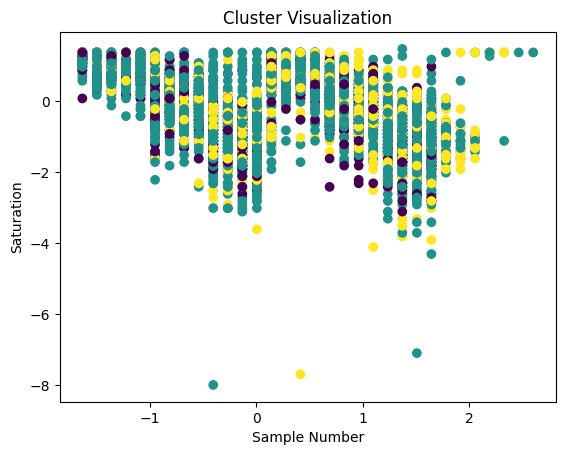

In [12]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Load Your Dataset
data = pd.read_csv('/content/pulseoximeter.csv')

# Handle Missing Values
imputer = SimpleImputer(strategy='mean')
data[['device', 'probe_location', 'sample_number', 'saturation', 'pi']] = imputer.fit_transform(data[['device', 'probe_location', 'sample_number', 'saturation', 'pi']])

# Standardize the Data
scaler = StandardScaler()
data[['device', 'probe_location', 'sample_number', 'saturation', 'pi']] = scaler.fit_transform(data[['device', 'probe_location', 'sample_number', 'saturation', 'pi']])

from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans

# Train/Test Split
X = data[['device', 'probe_location', 'sample_number', 'saturation', 'pi']]
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

# Train a Clustering Model (K-Means)
kmeans = KMeans(n_clusters=3, random_state=42)  # Adjust the number of clusters as needed
kmeans.fit(X_train)

# Predict Clusters for the Test Set
clusters = kmeans.predict(X_test)
X_test['Cluster'] = clusters



# Visualize Clusters
import matplotlib.pyplot as plt

plt.scatter(X_test['sample_number'], X_test['saturation'], c=X_test['Cluster'])
plt.xlabel('Sample Number')
plt.ylabel('Saturation')
plt.title('Cluster Visualization')
plt.show()



Classification of pluseoximeter

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


[[8752]]
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      8752

    accuracy                           1.00      8752
   macro avg       1.00      1.00      1.00      8752
weighted avg       1.00      1.00      1.00      8752



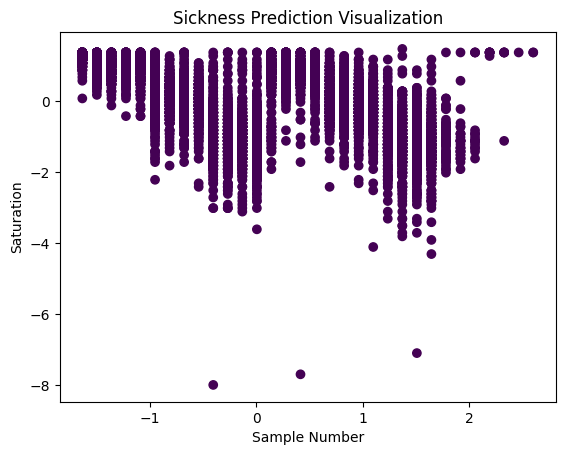

In [13]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Load Your Dataset
data = pd.read_csv('/content/pulseoximeter.csv')

# Handle Missing Values
imputer = SimpleImputer(strategy='mean')
data[['device', 'probe_location', 'sample_number', 'saturation', 'pi']] = imputer.fit_transform(data[['device', 'probe_location', 'sample_number', 'saturation', 'pi']])

# Standardize the Data
scaler = StandardScaler()
data[['device', 'probe_location', 'sample_number', 'saturation', 'pi']] = scaler.fit_transform(data[['device', 'probe_location', 'sample_number', 'saturation', 'pi']])

# Create Target Variable for Sickness
data['is_sick'] = np.where(data['saturation'] < 90, 1, 0)

# Train/Test Split
X = data[['device', 'probe_location', 'sample_number', 'saturation', 'pi']]
y = data['is_sick']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Classifier Model (Random Forest)
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Predict on the Test Set
y_pred = clf.predict(X_test)

# Evaluate the Model
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Visualize the Results
plt.scatter(X_test['sample_number'], X_test['saturation'], c=y_pred, cmap='viridis')
plt.xlabel('Sample Number')
plt.ylabel('Saturation')
plt.title('Sickness Prediction Visualization')
plt.show()


SpO2 the wake forms data

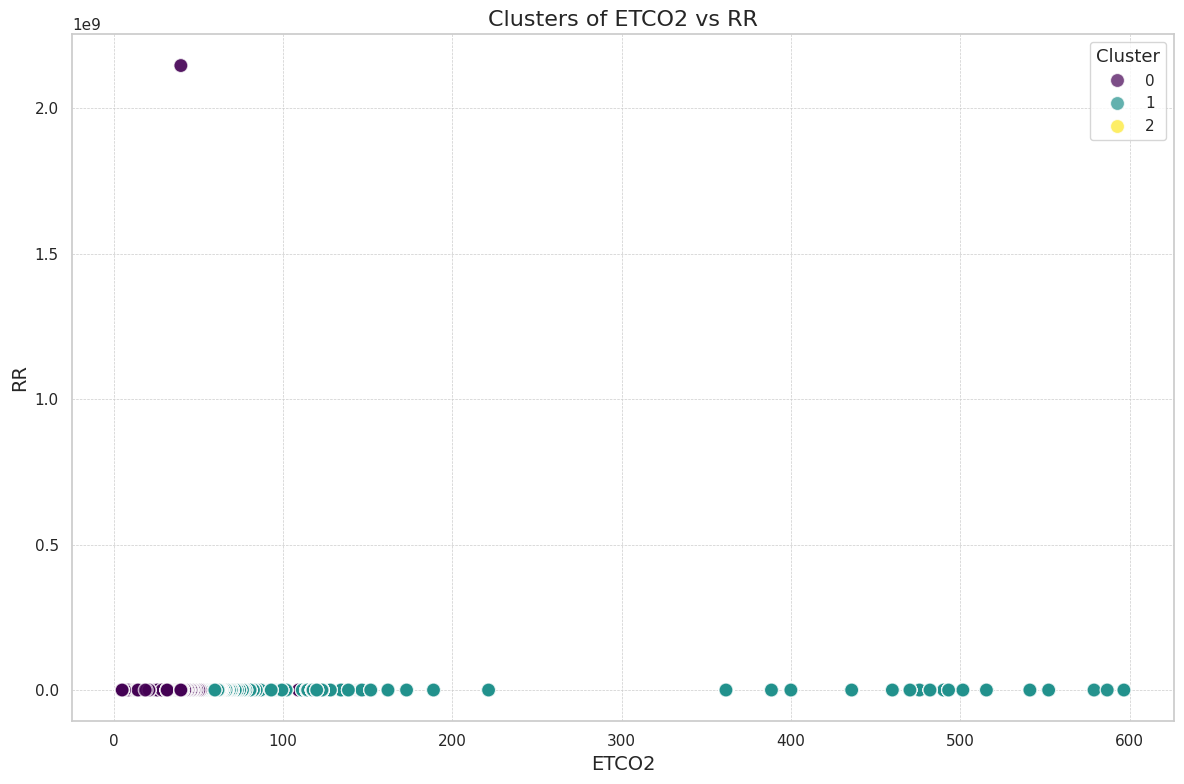

In [35]:
import pandas as pd
import glob
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Read all CSV files
path = '/content/Sp02'
all_files = glob.glob(path + "/*.csv")

df_list = []
for filename in all_files:
    df = pd.read_csv(filename)
    df_list.append(df)

combined_df = pd.concat(df_list, axis=0, ignore_index=True)

# Drop columns with all missing values
combined_df = combined_df.dropna(axis=1, how='all')

# Step 2: Standardize the data to fill in missing columns
# Impute missing values with the mean of each column
numeric_columns = combined_df.select_dtypes(include=['number']).columns
standardized_df = combined_df.copy()
imputer = SimpleImputer(strategy='mean')
standardized_df[numeric_columns] = imputer.fit_transform(standardized_df[numeric_columns])

# Check for 'Sample' and 'Timestamp' columns before dropping them
columns_to_drop = ['Sample', 'Timestamp']
columns_to_drop = [col for col in columns_to_drop if col in numeric_columns]

# Step 3: Train a machine learning model to find clusters and visualize the data
# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(standardized_df[numeric_columns].drop(columns=columns_to_drop))

# Train KMeans clustering model
kmeans = KMeans(n_clusters=3)  # Adjust the number of clusters as needed
kmeans.fit(scaled_data)
standardized_df['Cluster'] = kmeans.labels_

# Visualize the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=standardized_df['ETCO2'], y=standardized_df['RR'], hue=standardized_df['Cluster'], palette='viridis')
plt.title('Clusters of ETCO2 vs RR')
plt.xlabel('ETCO2')
plt.ylabel('RR')
plt.show()


silloutte score stuff

For n_clusters = 2, the average silhouette_score is 0.7061908820682691
For n_clusters = 3, the average silhouette_score is 0.5399692385756869
For n_clusters = 4, the average silhouette_score is 0.2335922777800426
For n_clusters = 5, the average silhouette_score is 0.269039271915839
For n_clusters = 6, the average silhouette_score is 0.25833212615531814
For n_clusters = 7, the average silhouette_score is 0.2605765447330076
For n_clusters = 8, the average silhouette_score is 0.18320860795732236
For n_clusters = 9, the average silhouette_score is 0.2925706891033917
For n_clusters = 10, the average silhouette_score is 0.279926491249531


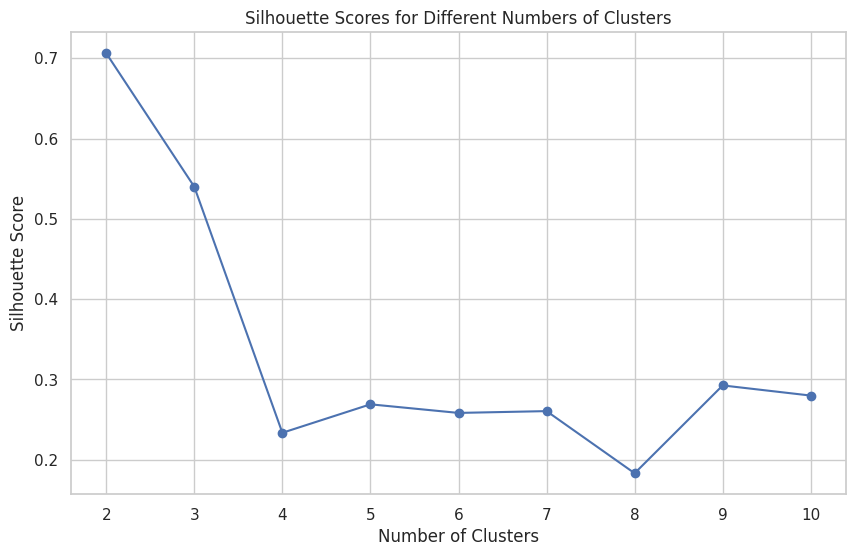

In [36]:
import pandas as pd
import glob
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Read all CSV files
path = '/content/Sp02'
all_files = glob.glob(path + "/*.csv")

df_list = []
for filename in all_files:
    df = pd.read_csv(filename)
    df_list.append(df)

combined_df = pd.concat(df_list, axis=0, ignore_index=True)

# Drop columns with all missing values
combined_df = combined_df.dropna(axis=1, how='all')

# Step 2: Standardize the data to fill in missing columns
# Impute missing values with the mean of each column
numeric_columns = combined_df.select_dtypes(include=['number']).columns
standardized_df = combined_df.copy()
imputer = SimpleImputer(strategy='mean')
standardized_df[numeric_columns] = imputer.fit_transform(standardized_df[numeric_columns])

# Check for 'Sample' and 'Timestamp' columns before dropping them
columns_to_drop = ['Sample', 'Timestamp']
columns_to_drop = [col for col in columns_to_drop if col in numeric_columns]

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(standardized_df[numeric_columns].drop(columns=columns_to_drop))

# Step 3: Evaluate different numbers of clusters using silhouette score
range_n_clusters = [2, 3, 4, 5, 6, 7, 8, 9, 10]
silhouette_scores = []

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters)
    cluster_labels = kmeans.fit_predict(scaled_data)
    silhouette_avg = silhouette_score(scaled_data, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"For n_clusters = {n_clusters}, the average silhouette_score is {silhouette_avg}")

# Plot silhouette scores for different numbers of clusters
plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, silhouette_scores, marker='o')
plt.title('Silhouette Scores for Different Numbers of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()
